# Three-Inside-Up / Down — a quantitative teardown 🔬
### Mechanical harami + confirmation on 5 indices · forward returns · one-sample HAC *t* · a drift-matched random-entry baseline · a confirmation-candle (harami-only) placebo · costs · a synthetic planted-reversal control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Confirmation_adds_edge%3F: Busted](https://img.shields.io/badge/Confirmation_adds_edge%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The job is twofold: (1) separate the **pattern** from the **drift** (random-entry baseline), and (2) isolate the **confirmation candle's** marginal contribution by re-running on the bare harami. The thesis on trial is exactly that second question.

> ⚠️ **Data note.** 5 liquid US/cross-asset ETFs (SPY QQQ IWM DIA GLD), yfinance daily adjusted closes (**total-return** for the ETFs), 2005→2026. The pattern is read on **closed** bars; entry is the **next close** (one documented lag). Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from three_inside import data, strategy as st

ASOF = "2026-05-31"
HAVE_REAL = data.have_real()
def load(t):
    b = data.load_real(t, allow_fetch=False)
    return b[b.index <= ASOF]
print("real three-inside cache present:", HAVE_REAL, "| tickers:", data.DEFAULT_TICKERS)

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-05-31', 'start': '2005-01-03', 'end': '2026-05-29', 'years': 21.4, 'tickers': ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD'], 'n_entries': 64, 'tl': 5, 'fp_spy': '4cb5244f3990', 'h5': (5, 64, 30.4, 61, 1.22, 10.3, 20.1, 28.4, 0.63, 0.528), 'h10': (10, 64, 10.3, 62, 0.25, 53.6, -43.2, 8.3, -0.86, 0.392), 'h20': (20, 64, -106.9, 47, -1.61, 33.1, -139.9, -108.9, -1.75, 0.083), 'h60': (60, 64, -13.3, 48, -0.12, 118.9, -132.3, -15.3, -1.04, 0.302), 'per': [('SPY', 11, -177.4, -1.08, 39.3, -216.7), ('QQQ', 14, -136.3, -0.62, 88.2, -224.5), ('IWM', 18, -107.6, -1.21, 2.7, -110.3), ('DIA', 11, -93.3, -0.97, 33.7, -127.0), ('GLD', 10, -1.6, -0.01, 1.5, -3.1)], 'placebo': (64, -106.9, 211, 91.4, -198.3, -2.49, 0.015), 'syn': [(0.0, 20, -87.1, 45, -1.18), (0.6, 20, 341.6, 75, 4.43)]}


real three-inside cache present: True | tickers: ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD']


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Confirmed three-inside-up vs a **drift-matched random** baseline: Δ = +20/-43/-140/-132 bps at 5/10/20/60d; the Welch *t* **never clears 2** (min -1.75 at 20d). The rule's own one-sample *t* never clears 2 and turns negative at 20d. |
| **Tradability** | `MIRAGE` | Only **64** signals in 21 years across 5 tapes; the confirmed entry loses to random in **5 of 5** names (20d t = -1.61, negative). No drift to inherit, nothing to scale. |
| **Confirmation adds edge?** | `BUSTED` | Dropping the confirmation candle (harami-only placebo) **improves** the 20d return by **198 bps** (+91 vs -107); Welch *t* = -2.49 (*p* = 0.015). The third candle is a *negative* contributor. |

> 💡 In plain words: the pattern doesn't even ride the drift (it loses to random), and the bit everyone trusts — the confirmation candle — is the worst part of the rule.

## 1 · The claim, steelmanned

After a downtrend, bars A,B,C with bodies $[\,\underline b_i,\overline b_i\,]$. **A** is a down candle ($C_A<O_A$); **B** is a harami ($\overline h_B\le\overline b_A$ and $\underline\ell_B\ge\underline b_A$, the range inside A's body); **C** confirms ($C_C>O_A$ and $C_C>C_B$). The rule buys on C's close (entered next close) and holds H days.

- **H₀ (drift).** Confirmed returns equal a drift-matched **random-entry** baseline.
- **H₁ (the pattern forecasts).** Confirmed returns **exceed** random at some horizon, t ≥ 2.
- **H₂ (the confirmation candle matters).** Confirmed returns **exceed** the bare **harami-only** entry (confirmation removed).

We find **H₀ not rejected** (confirmed ≤ random at 10–60d), **H₁ rejected** (Welch t never ≥ 2; the rule even goes negative), and **H₂ rejected the wrong way** (confirmation *subtracts* edge, Welch t ≈ −2.5). The steelman fails on every leg.

## 2 · So what? — the two confounds this design must kill

**(a) Drift.** Equity indices have a positive unconditional daily mean; a one-sample $t$ of a long-only rule against **zero** measures the tide, not the tool. The fix is the **random-entry baseline** (same instrument, epoch, hold) and a Welch test of confirmed-*minus*-random. (Here the rule loses even this, which is a stronger refutation.)

**(b) The confirmation candle as the load-bearing claim.** The three-inside-up's whole selling point over the two-candle harami is the confirming third candle. The honest test is to **remove it** — the **harami-only placebo** keeps the down-candle-plus-inside-bar event but drops the confirmation, so the difference is the confirmation candle's *marginal* contribution. If it's ≤ 0, the third candle is decorative (or worse).

## 3 · How we'd know — the protocol

- **Universe.** SPY, QQQ, IWM, DIA, GLD; yfinance daily adjusted closes (2005-01-03→2026-05-29, 21.4y). **64 confirmed signals** pooled.
- **Pattern.** A: down candle after a 5-day downtrend. B: range inside A's body (strict harami). C: close > A's open and > B's close. All on **closed** bars.
- **Entry.** On C's close; enter **next close** (one lag); hold H ∈ {5,10,20,60}.
- **Null #1 — one-sample HAC t** of confirmed returns vs 0 (Newey-West).
- **Null #2 — random-entry baseline**, Welch two-sample confirmed vs random (the drift test).
- **Null #3 — harami-only placebo** (confirmation removed), Welch confirmed vs harami (**the thesis test**).
- **Costs.** 1 bp one-way × 2 legs on every signal.
- **Positive control.** Synthetic tape with a **planted** post-three-inside-up bounce (knob `edge`): edge=0 must NOT reach significance; edge>0 must light up.

## 4 · The teardown

### 4a · One-sample t vs the random baseline

Left: the confirmed pattern's **one-sample** t against zero. Right: the same confirmed entry vs a **drift-matched random** baseline (Welch). Neither clears 2; both go negative at 20d.

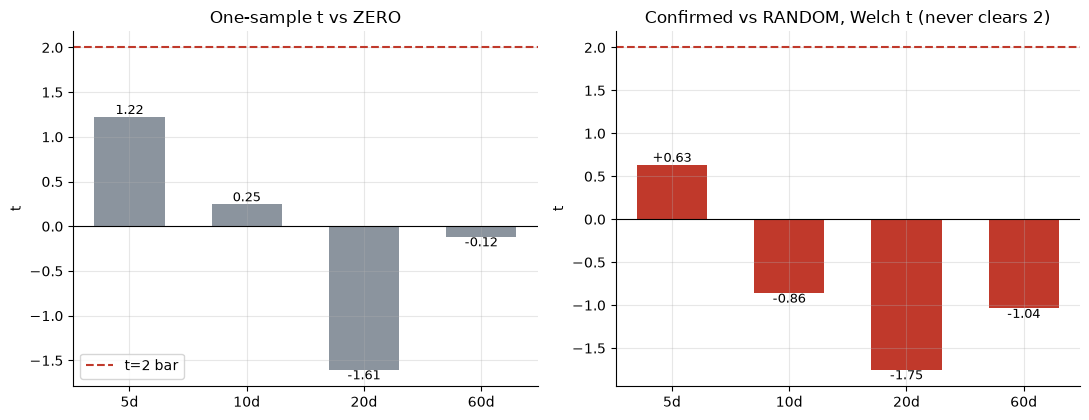

one-sample t: [1.22, 0.25, -1.61, -0.12]
welch vs random: [np.float64(0.63), np.float64(-0.86), np.float64(-1.75), np.float64(-1.04)]


In [2]:
hs = [5, 10, 20, 60]
if HAVE_REAL:
    one_t, conf, rnd, welch = [], [], [], []
    from scipy import stats
    for h in hs:
        tt, rr = [], []
        for t in data.DEFAULT_TICKERS:
            bb = load(t); c = bb['close']
            e = st.three_inside_entries(bb, trend_lookback=R['tl'], require_confirm=True)
            re = st.random_entries(c, max(len(e),50), seed=7)
            tt.append(st.forward_returns(c, e, h)); rr.append(st.forward_returns(c, re, h))
        tt = np.concatenate(tt); rr = np.concatenate(rr)
        one_t.append(st.summarize(tt)['t']); conf.append(tt.mean()*1e4); rnd.append(rr.mean()*1e4)
        welch.append(stats.ttest_ind(tt, rr, equal_var=False)[0])
else:
    one_t = [R['h5'][4], R['h10'][4], R['h20'][4], R['h60'][4]]
    conf = [R['h5'][2], R['h10'][2], R['h20'][2], R['h60'][2]]
    rnd = [R['h5'][5], R['h10'][5], R['h20'][5], R['h60'][5]]
    welch = [R['h5'][8], R['h10'][8], R['h20'][8], R['h60'][8]]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.3))
a1.bar([f'{h}d' for h in hs], one_t, color=GREY, width=.6)
a1.axhline(2, ls='--', c=RED, label='t=2 bar'); a1.axhline(0, c='k', lw=.8)
for i,v in enumerate(one_t): a1.annotate(f'{v:.2f}',(i,v),ha='center',va='bottom' if v>=0 else 'top',fontsize=9)
a1.set_title('One-sample t vs ZERO'); a1.set_ylabel('t'); a1.legend()
a2.bar([f'{h}d' for h in hs], welch, color=[GREEN if v>2 else RED for v in welch], width=.6)
a2.axhline(2, ls='--', c=RED); a2.axhline(0, c='k', lw=.8)
for i,v in enumerate(welch): a2.annotate(f'{v:+.2f}',(i,v),ha='center',va='bottom' if v>=0 else 'top',fontsize=9)
a2.set_title('Confirmed vs RANDOM, Welch t (never clears 2)'); a2.set_ylabel('t')
plt.tight_layout(); plt.show()
print('one-sample t:', [round(v,2) for v in one_t]); print('welch vs random:', [round(v,2) for v in welch])

> 💡 In plain words: there's no beta mirage to strip here — the confirmed pattern's own one-sample t never clears 2 (20d **-1.61**, negative). Against random it's negative at 10/20/60d (Welch -1.75 at 20d). The pattern doesn't forecast a reversal; it mostly precedes more weakness.

### 4b · Confirmed vs random across horizons

Mean return, confirmed three-inside-up vs random entry, all four horizons. The pattern should tower over random if it forecasts. It doesn't — and goes negative at 20d.

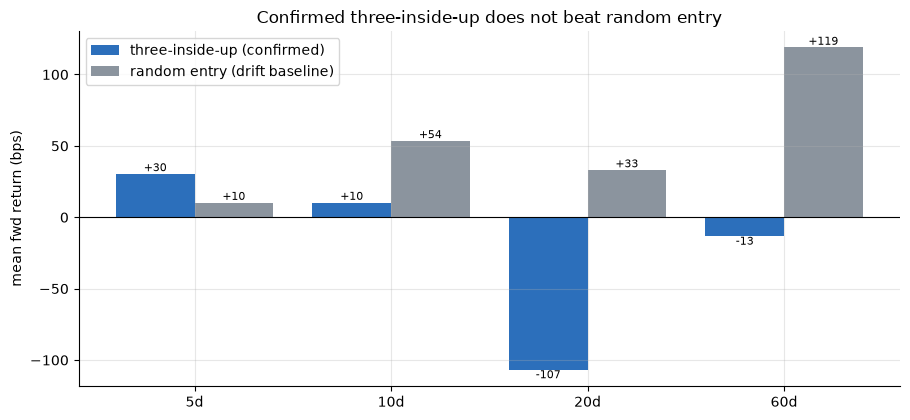

delta confirmed-random (bps): [20, -43, -140, -132]


In [3]:
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.bar(x-.2, conf, .4, color='#2c6fbb', label='three-inside-up (confirmed)')
ax.bar(x+.2, rnd, .4, color=GREY, label='random entry (drift baseline)')
ax.axhline(0, c='k', lw=.8)
for i,(a,b) in enumerate(zip(conf,rnd)):
    ax.annotate(f'{a:+.0f}',(i-.2,a),ha='center',va='bottom' if a>=0 else 'top',fontsize=8)
    ax.annotate(f'{b:+.0f}',(i+.2,b),ha='center',va='bottom' if b>=0 else 'top',fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs]); ax.set_ylabel('mean fwd return (bps)')
ax.set_title('Confirmed three-inside-up does not beat random entry'); ax.legend()
plt.tight_layout(); plt.show()
print('delta confirmed-random (bps):', [round(a-b) for a,b in zip(conf,rnd)])

> 💡 In plain words: at 20 days the confirmed pattern is **-107 bps** while random is **+33 bps** — the famous reversal *underperforms* a dart by 140 bps. Only at 5d is it ahead, and the Welch test (4a) says even that is noise.

### 4c · The confirmation-candle placebo — the thesis test

Drop the confirmation candle and fire on the bare harami (same down-candle-plus-inside-bar event, no third candle). If the confirmation adds edge, the confirmed bar should beat the harami bar. It's the **opposite**.

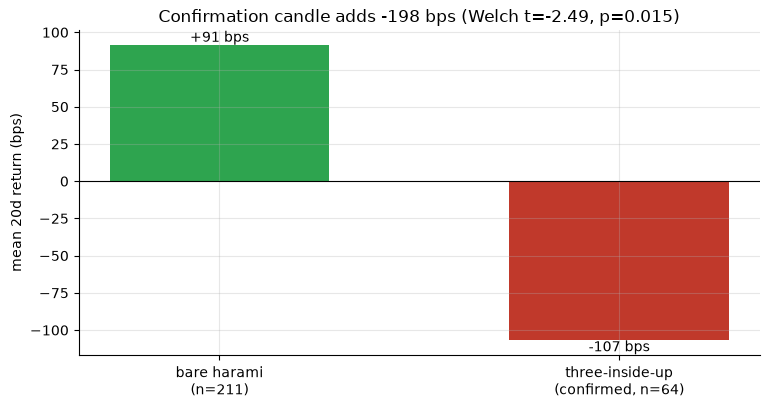

harami-only: +91.4 bps (n=211)   confirmed: -106.9 bps (n=64)
confirmation marginal = -198.3 bps   Welch t=-2.49  p=0.015


In [4]:
if HAVE_REAL:
    from scipy import stats
    cf, hr = [], []
    for t in data.DEFAULT_TICKERS:
        bb = load(t); c = bb['close']
        ec = st.three_inside_entries(bb, trend_lookback=R['tl'], require_confirm=True)
        eh = st.three_inside_entries(bb, trend_lookback=R['tl'], require_confirm=False)
        cf.append(st.forward_returns(c, ec, 20)); hr.append(st.forward_returns(c, eh, 20))
    cf = np.concatenate(cf); hr = np.concatenate(hr)
    conf_m = cf.mean()*1e4; har_m = hr.mean()*1e4
    wt, wp = stats.ttest_ind(cf, hr, equal_var=False)
    n_c, n_h = cf.size, hr.size
else:
    n_c, conf_m, n_h, har_m, _, wt, wp = R['placebo']
fig, ax = plt.subplots(figsize=(7.8, 4.2))
ax.bar([f'bare harami\n(n={n_h})','three-inside-up\n(confirmed, n={})'.format(n_c)],
       [har_m, conf_m], color=[GREEN, RED], width=.55)
ax.axhline(0, c='k', lw=.8)
for i,v in enumerate([har_m, conf_m]): ax.annotate(f'{v:+.0f} bps',(i,v),ha='center',va='bottom' if v>=0 else 'top')
ax.set_ylabel('mean 20d return (bps)'); ax.set_title(f'Confirmation candle adds {conf_m-har_m:+.0f} bps (Welch t={wt:+.2f}, p={wp:.3f})')
plt.tight_layout(); plt.show()
print(f'harami-only: {har_m:+.1f} bps (n={n_h})   confirmed: {conf_m:+.1f} bps (n={n_c})')
print(f'confirmation marginal = {conf_m-har_m:+.1f} bps   Welch t={wt:+.2f}  p={wp:.3f}')

> 💡 In plain words: the bare harami averages **+91 bps**; the confirmed version **-107 bps**. The confirmation candle's marginal contribution is **-198 bps** — significantly *negative* (Welch t = -2.49, p = 0.015). Requiring an up-close third candle means buying after a one-day pop: you chase, and pay for it. **Thesis busted.**

### 4d · Per-ticker (H = 20) — confirmed loses to random everywhere

20-day confirmed-minus-random delta, per instrument. If the pattern worked it would be positive; it's negative in all 5.

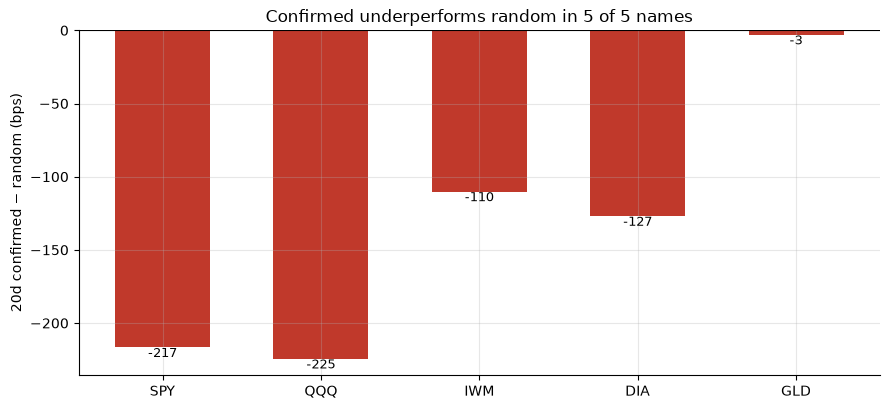

per-ticker 20d delta (bps): {'SPY': -217, 'QQQ': -225, 'IWM': -110, 'DIA': -127, 'GLD': -3}


In [5]:
if HAVE_REAL:
    names, deltas = [], []
    for t in data.DEFAULT_TICKERS:
        bb = load(t); c = bb['close']
        e = st.three_inside_entries(bb, trend_lookback=R['tl'], require_confirm=True)
        re = st.random_entries(c, max(len(e),50), seed=7)
        d = st.summarize(st.forward_returns(c,e,20))['mean_bps'] - st.summarize(st.forward_returns(c,re,20))['mean_bps']
        names.append(t); deltas.append(d)
else:
    names = [p[0] for p in R['per']]; deltas = [p[5] for p in R['per']]
fig, ax = plt.subplots(figsize=(9.0, 4.2))
ax.bar(names, deltas, color=[GREEN if d>0 else RED for d in deltas], width=.6)
ax.axhline(0, c='k', lw=.8)
for i,d in enumerate(deltas): ax.annotate(f'{d:+.0f}',(i,d),ha='center',va='bottom' if d>=0 else 'top',fontsize=9)
ax.set_ylabel('20d confirmed − random (bps)'); ax.set_title('Confirmed underperforms random in 5 of 5 names')
plt.tight_layout(); plt.show()
print('per-ticker 20d delta (bps):', {n:round(d) for n,d in zip(names,deltas)})

> 💡 In plain words: every name is negative, from GLD's tiny **-3 bps** to QQQ's **-224 bps**. No coherent cross-sectional edge — the pattern is rare and, where it fires, it loses to a dart.

### 4e · Synthetic positive control — the harness CAN bank a real reversal

To prove the null is honest (not a dead detector), plant a **real** post-three-inside-up bounce into a synthetic tape and check the same confirmed rule banks it: edge=0 must stay below significance; edge>0 must light up.

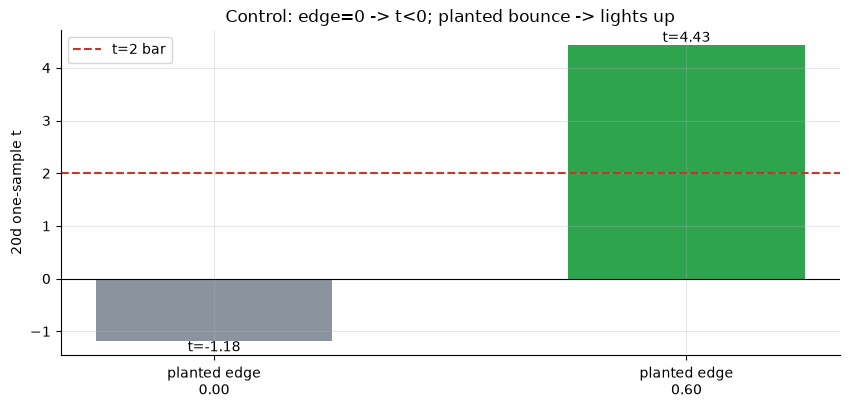

edge=0.00: n=20 conf=-87.1bps win=45% t=-1.18
edge=0.60: n=20 conf=+341.6bps win=75% t=+4.43


In [6]:
res = []
for edge in (0.0, 0.60):
    px, _ = data.synthetic_panel(edge=edge, seed=453, n_days=8000)
    c = px['close']; e = st.three_inside_entries(px, trend_lookback=R['tl'], require_confirm=True)
    s = st.summarize(st.forward_returns(c, e, 20))
    res.append((edge, s['n'], s['mean_bps'], s['win']*100, s['t']))
fig, ax = plt.subplots(figsize=(8.6, 4.2))
labels = [f'planted edge\n{e:.2f}' for e,_,_,_,_ in res]; tvals = [r[4] for r in res]
ax.bar(labels, tvals, color=[GREY, GREEN], width=.5)
ax.axhline(2, ls='--', c=RED, label='t=2 bar'); ax.axhline(0, c='k', lw=.8)
for i,t in enumerate(tvals): ax.annotate(f't={t:.2f}',(i,t),ha='center',va='bottom' if t>=0 else 'top')
ax.set_ylabel('20d one-sample t'); ax.set_title('Control: edge=0 -> t<0; planted bounce -> lights up'); ax.legend()
plt.tight_layout(); plt.show()
for e,n,m,w,t in res: print(f'edge={e:.2f}: n={n} conf={m:+.1f}bps win={w:.0f}% t={t:+.2f}')

> 💡 In plain words: with **no** planted bounce the control sits at **t = -1.18** (win 45% — no false positive); a planted bounce reaches **t = 4.43** (win 75%). The detector works — so the flat/negative real-tape result is a genuine 'nothing there', not a broken pipeline.

## 5 · The verdict

- **Signal `NONE`** — the confirmed three-inside-up does not beat a drift-matched random baseline (confirmed − random = +20/-43/-140/-132 bps at 5/10/20/60d; Welch t never clears 2). The rule's own one-sample t never clears 2 and turns negative (20d **-1.61**) — no beta mirage, just no edge.
- **Tradability `MIRAGE`** — 64 signals in 21 years, losing to random in 5 of 5 names; costs only deepen the hole. Nothing to scale.
- **Confirmation adds edge? `BUSTED`** — the harami-only placebo *improves* the 20d return by **198 bps** (+91 vs -107; Welch t = -2.49, p = 0.015). The confirmation candle — the heart of the pattern — is a *negative* contributor.

## 6 · Could you trade it? — there is nothing to trade

The confirmed three-inside-up fires rarely, loses to a random-day entry in every name, and its defining confirmation candle subtracts edge. There is no drift to inherit and no residual signal to scale; costs on each rare signal make it worse. The pattern is a descriptive label for a wiggle, not a forecasting strategy — and the part of it the lore trusts most is the part that hurts.

## 7 · Going further

- **The bare harami on its own terms.** It beat the confirmed version here; a follow-up tests whether the two-candle harami clears the random baseline (spoiler: still no, but it's *less* bad — the confirmation is the active poison).
- **The mirror three-inside-down.** The bearish top pattern inherits the same confirmation-as-chasing problem in reverse.
- **Confirmation strength.** Vary the confirmation threshold (close past A's high vs A's open); the stronger the required up-close, the more you chase — a clean monotone of the negative-contribution result.

*Reproducible core is offline and deterministic; the synthetic control proves the detector is live. Methods/sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*